# Land Use Classification
This notebook demonstrates a complete deep learning pipeline for classifying satellite imagery into different land use categories. The goal is to build a Convolutional Neural Network (CNN) that can accurately identify various types of land use from aerial photographs, which has applications in urban planning, environmental monitoring, and geographic information systems.

**Dataset Information:**

* **Source**: UC Merced Land Use Dataset
* **Features**: RGB satellite images (256×256 pixels)
* **Classes**: 21 land use categories (configurable for faster training)
* **Size**: 2,100 images total (100 images per class)
* **Image Format**: TIFF format, high-resolution overhead imagery


**Land Use Categories:**
* `agricultural`: Farmland and cultivated areas
* `airplane`: Aircraft on tarmac or runways
* `baseballdiamond`: Baseball fields and diamonds
* `beach`: Coastal sandy areas
* `buildings`: Dense urban structures
* `chaparral`: Shrubland vegetation
* `denseresidential`: High-density housing areas
* `forest`: Tree-covered regions
* `freeway`: Highway systems and interchanges
* `golfcourse`: Golf course facilities
* `harbor`: Port and marina areas
* `intersection`: Road intersections
* `mediumresidential`: Medium-density housing
* `mobilehomepark`: Mobile home communities
* `overpass`: Highway overpasses and bridges
* `parkinglot`: Vehicle parking areas
* `river`: Waterways and rivers
* `runway`: Airport runways
* `sparseresidential`: Low-density housing
* `storagetanks`: Industrial storage facilities
* `tenniscourt`: Tennis court facilities


## 1. Setup

In [1]:
# Install required packages
import sys
!{sys.executable} -m pip install torch torchvision matplotlib seaborn scikit-learn pandas numpy pillow requests tqdm -q

In [2]:
# Import libraries
import os
import requests
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from functools import partial
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split


# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Dataset

In [3]:
# Download and extract UC Merced Land Use Dataset
data_dir = '/home/land_use_data'
os.makedirs(data_dir, exist_ok=True)

dataset_url = 'http://weegee.vision.ucmerced.edu/datasets/UCMerced_LandUse.zip'
zip_path = os.path.join(data_dir, 'UCMerced_LandUse.zip')

if not os.path.exists(os.path.join(data_dir, 'UCMerced_LandUse')):
    print('Downloading UC Merced Land Use Dataset...')
    response = requests.get(dataset_url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(zip_path, 'wb') as f:
        with tqdm(total=total_size, unit='B', unit_scale=True) as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                pbar.update(len(chunk))

    print('Extracting dataset...')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)

    os.remove(zip_path)
    print('Dataset ready!')
else:
    print('Dataset already exists!')

dataset_path = os.path.join(data_dir, 'UCMerced_LandUse', 'Images')

100%|██████████| 332M/332M [00:22<00:00, 14.6MB/s]


Extracting dataset...
Dataset ready!


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Get all classes and count images
classes = sorted(os.listdir(dataset_path))
print(f'Number of classes: {len(classes)}')
print(f'\nClasses: {classes}')

# Count images per class
class_counts = {}
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len([f for f in os.listdir(class_path) if f.endswith('.tif')])

print(f'\nTotal images: {sum(class_counts.values())}')
print(f'Images per class: {class_counts[classes[0]]}')

Number of classes: 21

Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']

Total images: 2100
Images per class: 100


### Class distribution

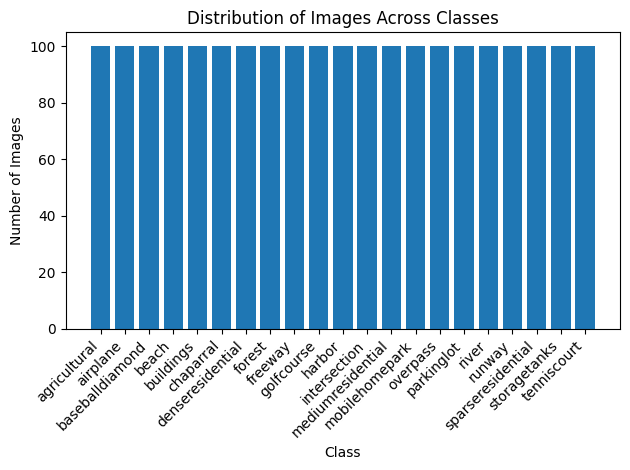

In [5]:
plt.figure()
plt.bar(range(len(class_counts)), list(class_counts.values()))
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images Across Classes')
plt.xticks(range(len(classes)), classes, rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Sample image from each class

In [6]:
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.ravel()

for idx, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith('.tif')]
    sample_image = os.path.join(class_path, image_files[0])

    img = Image.open(sample_image)
    axes[idx].imshow(img)
    axes[idx].set_title(class_name.replace('_', ' ').title())
    axes[idx].axis('off')

# Hide extra subplots
for idx in range(len(classes), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Image from Each Land Use Class')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Image properties (size, color distribution)

For five

In [7]:
sample_images = []
for class_name in classes[:5]:  # Sample from first 5 classes
    class_path = os.path.join(dataset_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith('.tif')]
    img_path = os.path.join(class_path, image_files[0])
    img = np.array(Image.open(img_path))
    sample_images.append(img)

# Check image dimensions
print(f'Image shape: {sample_images[0].shape}')
print(f'Image dtype: {sample_images[0].dtype}')
print(f'Pixel value range: [{sample_images[0].min()}, {sample_images[0].max()}]')

Image shape: (256, 256, 3)
Image dtype: uint8
Pixel value range: [52, 172]


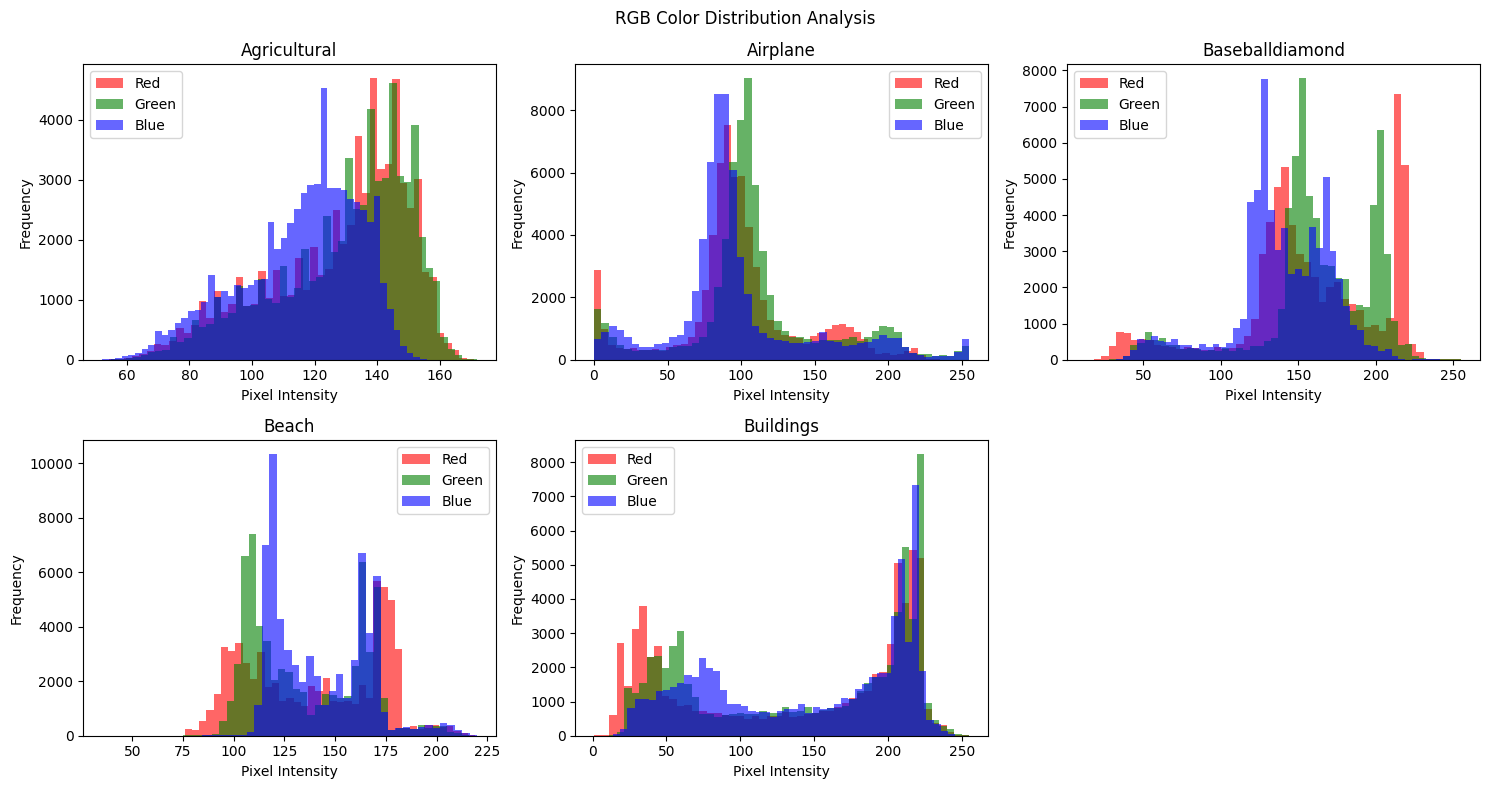

In [8]:
# Visualize color distribution for sample images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, (img, class_name) in enumerate(zip(sample_images, classes[:5])):
    row, col = idx // 3, idx % 3
    axes[row, col].hist(img[:,:,0].ravel(), bins=50, alpha=0.6, color='red', label='Red')
    axes[row, col].hist(img[:,:,1].ravel(), bins=50, alpha=0.6, color='green', label='Green')
    axes[row, col].hist(img[:,:,2].ravel(), bins=50, alpha=0.6, color='blue', label='Blue')
    axes[row, col].set_title(class_name.replace('_', ' ').title())
    axes[row, col].set_xlabel('Pixel Intensity')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

# Hide last subplot
axes[1, 2].axis('off')

plt.suptitle('RGB Color Distribution Analysis')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [9]:
# Number of classes to use (reduce for faster training)
# Set to None to use all 21 classes, or specify a number (e.g., 5, 10)
NUM_CLASSES_TO_USE = 5

In [10]:
# Function to load dataset
def load_land_use_dataset(root_dir, num_classes=None):
    """
    Load all image paths and labels from the land use dataset.

    Args:
        root_dir: Path to the dataset root directory
        num_classes: Number of classes to use (None for all classes)

    Returns:
        images: List of image file paths
        labels: List of corresponding labels (integers)
        classes: List of class names
        class_to_idx: Dictionary mapping class names to indices
    """
    all_classes = sorted(os.listdir(root_dir))

    # Select subset of classes if specified
    if num_classes is not None:
        classes = all_classes[:num_classes]
        print(f'Using {num_classes} classes out of {len(all_classes)} available')
        print(f'Selected classes: {classes}')
    else:
        classes = all_classes
        print(f'Using all {len(classes)} classes')

    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    images = []
    labels = []

    for class_name in classes:
        class_path = os.path.join(root_dir, class_name)
        for img_name in os.listdir(class_path):
            if img_name.endswith('.tif'):
                images.append(os.path.join(class_path, img_name))
                labels.append(class_to_idx[class_name])

    return images, labels, classes, class_to_idx

# Function to load and transform images into tensors
def load_images_as_tensors(image_paths, labels, transform=None):
    """
    Load images and apply transformations.

    Args:
        image_paths: List of image file paths
        labels: List of corresponding labels
        transform: Torchvision transforms to apply

    Returns:
        images_tensor: Tensor of transformed images
        labels_tensor: Tensor of labels
    """
    images_list = []

    for img_path in tqdm(image_paths, desc='Loading images'):
        image = Image.open(img_path).convert('RGB')
        if transform:
            image = transform(image)
        images_list.append(image)

    images_tensor = torch.stack(images_list)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    return images_tensor, labels_tensor

# Custom data loader function that loads images on-the-fly
def create_image_label_dataset(image_paths, labels):
    """
    Create a simple dataset that returns (image_path, label) pairs.

    Args:
        image_paths: List of image file paths
        labels: List of corresponding labels

    Returns:
        Dataset of (image_path, label) tuples
    """
    return list(zip(image_paths, labels))

# Custom collate function for DataLoader
def collate_fn(batch, transform=None):
    """
    Custom collate function to load and transform images on-the-fly.

    Args:
        batch: List of (image_path, label) tuples
        transform: Torchvision transforms to apply

    Returns:
        images: Batch of transformed images
        labels: Batch of labels
    """
    images = []
    labels = []

    for img_path, label in batch:
        image = Image.open(img_path).convert('RGB')
        if transform:
            image = transform(image)
        images.append(image)
        labels.append(label)

    images = torch.stack(images)
    labels = torch.tensor(labels, dtype=torch.long)

    return images, labels

In [11]:
# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25), #changed from 15 to 25
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print('Transforms defined successfully!')

Transforms defined successfully!


In [12]:
# Load dataset using the function with custom number of classes
all_images, all_labels, classes, class_to_idx = load_land_use_dataset(dataset_path, num_classes=NUM_CLASSES_TO_USE)

print(f'\nTotal images loaded: {len(all_images)}')
print(f'Total labels loaded: {len(all_labels)}')
print(f'Number of classes: {len(classes)}')
print(f'Images per class: ~{len(all_images) // len(classes)}')

# Split: 70% train, 15% validation, 15% test
train_size = int(0.7 * len(all_images))
val_size = int(0.15 * len(all_images))
test_size = len(all_images) - train_size - val_size

train_indices, temp_indices = train_test_split(
    range(len(all_images)),
    train_size=train_size,
    stratify=all_labels,
    random_state=42
)

temp_labels = [all_labels[i] for i in temp_indices]
val_indices, test_indices = train_test_split(
    temp_indices,
    train_size=val_size,
    stratify=temp_labels,
    random_state=42
)

print(f'\nDataset split:')
print(f'  Training: {len(train_indices)} images')
print(f'  Validation: {len(val_indices)} images')
print(f'  Testing: {len(test_indices)} images')

Using 5 classes out of 21 available
Selected classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings']

Total images loaded: 500
Total labels loaded: 500
Number of classes: 5
Images per class: ~100

Dataset split:
  Training: 350 images
  Validation: 75 images
  Testing: 75 images


In [13]:
# Create separate datasets with appropriate transforms
train_images = [all_images[i] for i in train_indices]
train_labels = [all_labels[i] for i in train_indices]

val_images = [all_images[i] for i in val_indices]
val_labels = [all_labels[i] for i in val_indices]

test_images = [all_images[i] for i in test_indices]
test_labels = [all_labels[i] for i in test_indices]

# Create datasets as list of tuples
train_dataset = create_image_label_dataset(train_images, train_labels)
val_dataset = create_image_label_dataset(val_images, val_labels)
test_dataset = create_image_label_dataset(test_images, test_labels)

print('Datasets created successfully!')
print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Datasets created successfully!
Train dataset size: 350
Validation dataset size: 75
Test dataset size: 75


## 5. Model Training and Comparison

In [14]:
# Function to create custom CNN model
def create_land_use_cnn(num_classes):
    """
    Create a lightweight CNN architecture for land use classification.

    Args:
        num_classes: Number of output classes

    Returns:
        model: PyTorch Sequential model
    """
    model = nn.Sequential(
        # Block 1
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 2
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 3
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        #extra depth
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),

        # Classifier
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(256, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.6),
        nn.Linear(128, num_classes)
    )

    return model

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create model with correct number of classes
num_classes = len(classes)
model_cnn = create_land_use_cnn(num_classes=num_classes).to(device)
print(f'Lightweight CNN Parameters: {count_parameters(model_cnn):,}')
print(f'Model output classes: {num_classes}')

Lightweight CNN Parameters: 422,917
Model output classes: 5


In [15]:
# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()


        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation', leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# Complete training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        if scheduler:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '/home/best_model.pth')
            print('Model saved!')

        print('-' * 60)

    return history

print('Training functions defined!')

Training functions defined!


### Fitting Model

In [16]:
batch_size = 32
learning_rate = 0.001
num_epochs = 15                                                                  # Reduced for faster training

print(f'Training configuration:')
print(f'  Number of classes: {len(classes)}')
print(f'  Batch Size: {batch_size}')
print(f'  Learning Rate: {learning_rate}')
print(f'  Epochs: {num_epochs}')
print(f'  Optimizer: Adam')
print(f'\nEstimated training time: ~{num_epochs * len(train_dataset) // (batch_size * 60)}-{num_epochs * len(train_dataset) // (batch_size * 30)} minutes')

Training configuration:
  Number of classes: 5
  Batch Size: 32
  Learning Rate: 0.001
  Epochs: 15
  Optimizer: Adam

Estimated training time: ~2-5 minutes


In [17]:
# Create data loaders
from functools import partial
train_collate = partial(collate_fn, transform=train_transform)
val_collate = partial(collate_fn, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                         num_workers=2, collate_fn=train_collate)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                       num_workers=2, collate_fn=val_collate)

print(f'Data loaders created:')
print(f'  Train batches: {len(train_loader)}')
print(f'  Validation batches: {len(val_loader)}')

Data loaders created:
  Train batches: 11
  Validation batches: 3


In [18]:
# Create model, loss, and optimizer
model = create_land_use_cnn(num_classes=len(classes)).to(device)

class_counts = np.bincount(train_labels)
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

learning_rate = 3e-4
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

print(f'Model created with {count_parameters(model):,} parameters')
print(f'Output classes: {len(classes)}')

Model created with 422,917 parameters
Output classes: 5


In [19]:
# Train the model
history = train_model(model, train_loader, val_loader, criterion, optimizer,
                     scheduler, num_epochs, device)

Epoch 1/15


Train Loss: 1.4865 | Train Acc: 40.29%
Val Loss: 1.5807 | Val Acc: 25.33%
Model saved!
------------------------------------------------------------
Epoch 2/15


Train Loss: 1.3111 | Train Acc: 54.00%
Val Loss: 1.4324 | Val Acc: 41.33%
Model saved!
------------------------------------------------------------
Epoch 3/15


Train Loss: 1.1353 | Train Acc: 70.00%
Val Loss: 1.1403 | Val Acc: 68.00%
Model saved!
------------------------------------------------------------
Epoch 4/15


Train Loss: 1.0948 | Train Acc: 64.86%
Val Loss: 0.9033 | Val Acc: 78.67%
Model saved!
------------------------------------------------------------
Epoch 5/15


...

Train Loss: 0.9139 | Train Acc: 73.71%
Val Loss: 0.6895 | Val Acc: 81.33%
------------------------------------------------------------
Epoch 12/15


Train Loss: 0.8939 | Train Acc: 69.71%
Val Loss: 0.6889 | Val Acc: 80.00%
------------------------------------------------------------
Epoch 13/15


Train Loss: 0.8621 | Train Acc: 70.86%
Val Loss: 0.6851 | Val Acc: 82.67%
------------------------------------------------------------
Epoch 14/15


Train Loss: 0.8752 | Train Acc: 71.43%
Val Loss: 0.6790 | Val Acc: 84.00%
Model saved!
------------------------------------------------------------
Epoch 15/15


Train Loss: 0.8724 | Train Acc: 71.14%
Val Loss: 0.6637 | Val Acc: 80.00%
------------------------------------------------------------


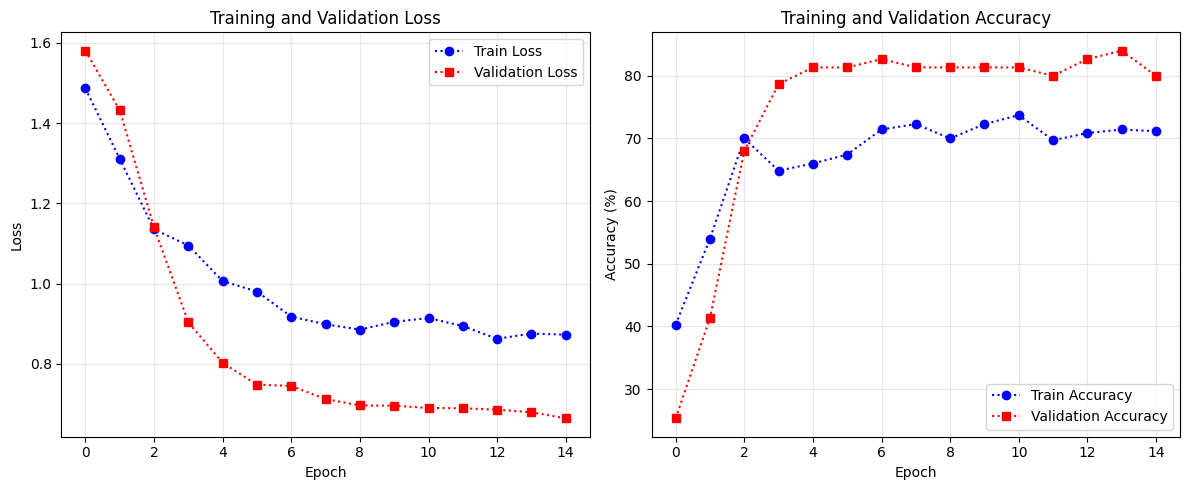


Best Training Accuracy: 73.71%
Best Validation Accuracy: 84.00%


In [20]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history['train_loss'], 'o:', color='blue', label='Train Loss')
axes[0].plot(history['val_loss'], 's:', color='red', label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], 'o:', color='blue', label='Train Accuracy')
axes[1].plot(history['val_acc'], 's:', color='red', label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nBest Training Accuracy: {max(history["train_acc"]):.2f}%')
print(f'Best Validation Accuracy: {max(history["val_acc"]):.2f}%')

### Evaluation

In [21]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('/home/best_model.pth'))
model.eval()

test_collate = partial(collate_fn, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, collate_fn=test_collate)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f'\nTest Accuracy: {test_accuracy * 100:.2f}%')

Testing: 100%|██████████| 3/3 [00:05<00:00,  1.83s/it]


Test Accuracy: 84.00%


### Classification report


In [22]:
print('Classification Report:')
report = classification_report(all_labels, all_preds, target_names=classes, digits=3)
print(report)

Classification Report:
                 precision    recall  f1-score   support

   agricultural      0.789     1.000     0.882        15
       airplane      0.706     0.800     0.750        15
baseballdiamond      1.000     0.533     0.696        15
          beach      0.938     1.000     0.968        15
      buildings      0.867     0.867     0.867        15

       accuracy                          0.840        75
      macro avg      0.860     0.840     0.832        75
   weighted avg      0.860     0.840     0.832        75



### Confusion matrix

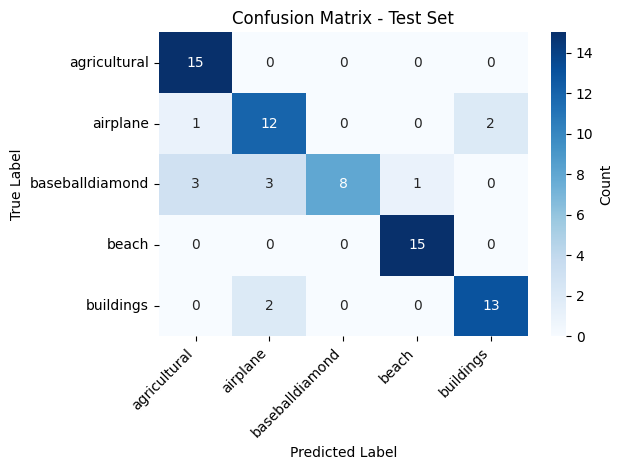

In [23]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

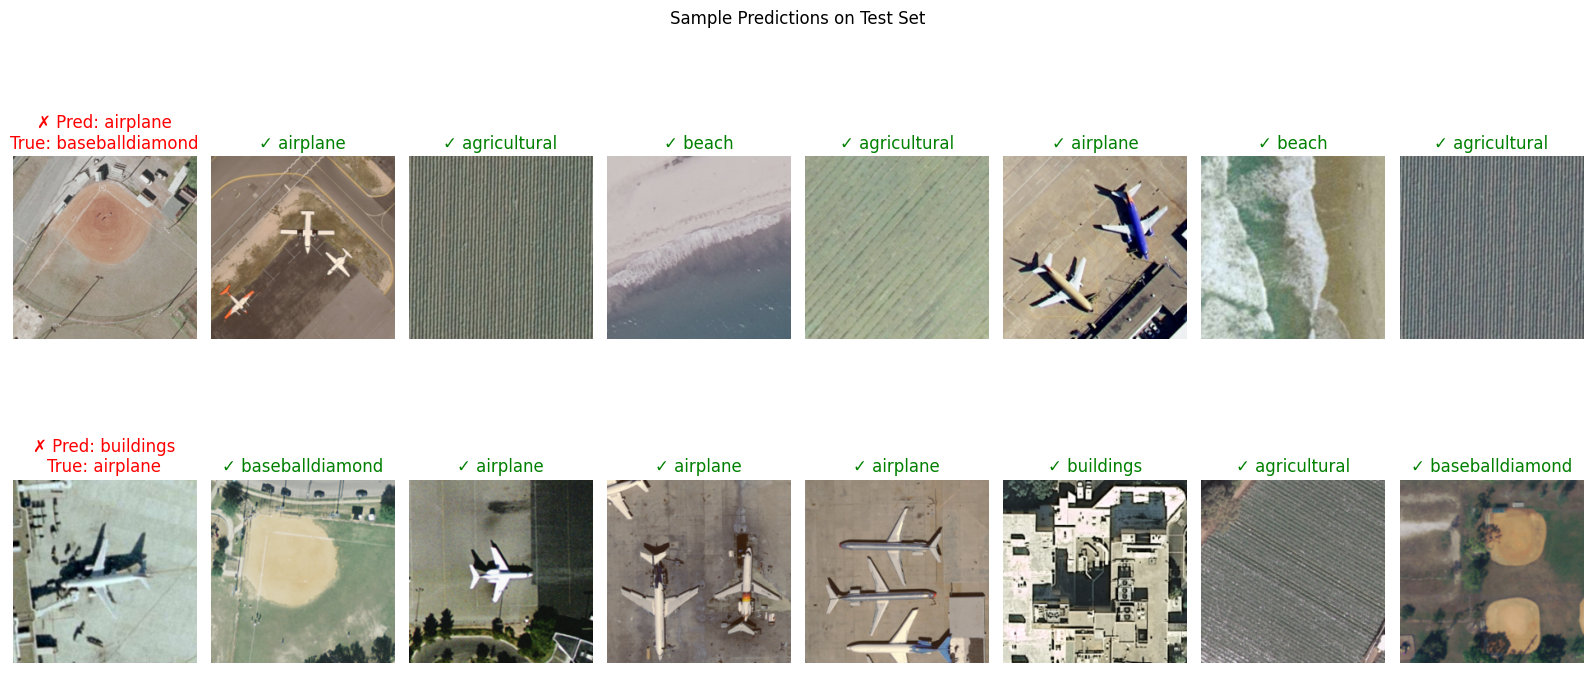

In [24]:
# Visualize correct and incorrect predictions
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Get some test samples
test_samples = []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        for i in range(min(8, len(images))):
            test_samples.append({
                'image': denormalize(images[i].cpu()),
                'true_label': labels[i].item(),
                'pred_label': predicted[i].item(),
                'correct': labels[i].item() == predicted[i].item()
            })

        if len(test_samples) >= 16:
            break

# Plot predictions
fig, axes = plt.subplots(2, 8, figsize=(16, 8))
axes = axes.ravel()

for idx, sample in enumerate(test_samples[:16]):
    img = sample['image'].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    axes[idx].imshow(img)

    true_class = classes[sample['true_label']]
    pred_class = classes[sample['pred_label']]

    if sample['correct']:
        color = 'green'
        title = f'✓ {pred_class}'
    else:
        color = 'red'
        title = f'✗ Pred: {pred_class}\nTrue: {true_class}'

    axes[idx].set_title(title, color=color)
    axes[idx].axis('off')

plt.suptitle('Sample Predictions on Test Set')
plt.tight_layout()
plt.show()